# Ensemble Methods: Why One Model Is Never Enough

---

## The case for combining models

Think about how decisions work in the real world. If you're sick, you might get a second opinion from another doctor. If you're judging a diving competition, you use a panel of judges and throw out the extreme scores. The pattern is always the same: **combining multiple independent judgments tends to be more reliable than trusting any single one**, especially when the individual judges make different kinds of mistakes.

Machine learning models work the same way. A decision tree might overfit to certain regions of the feature space. A logistic regression might underfit the non-linear parts. An SVM might be sensitive to its kernel choice. But if you ask all three and take a vote, the errors tend to cancel out: one model's blind spot is usually another model's strength.

This idea, training multiple models and combining their predictions, is called **ensemble learning**, and it's arguably the single most reliable way to improve performance on a given task. There are three main families of ensemble methods, each with a different strategy for creating and combining models:

- **Bagging**: Train the *same* algorithm on different random subsets of the data, then average. Reduces variance.
- **Boosting**: Train models *sequentially*, where each one focuses on what the previous ones got wrong. Reduces bias.
- **Stacking / Voting**: Combine *different* algorithms and let a meta-model (or a simple vote) decide how to blend them.

Let's build up from single models and see each of these in action.

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification, make_moons, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, 
    AdaBoostClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. The Problem: Single Model Limitations

Let's first see why a single model might not be enough:

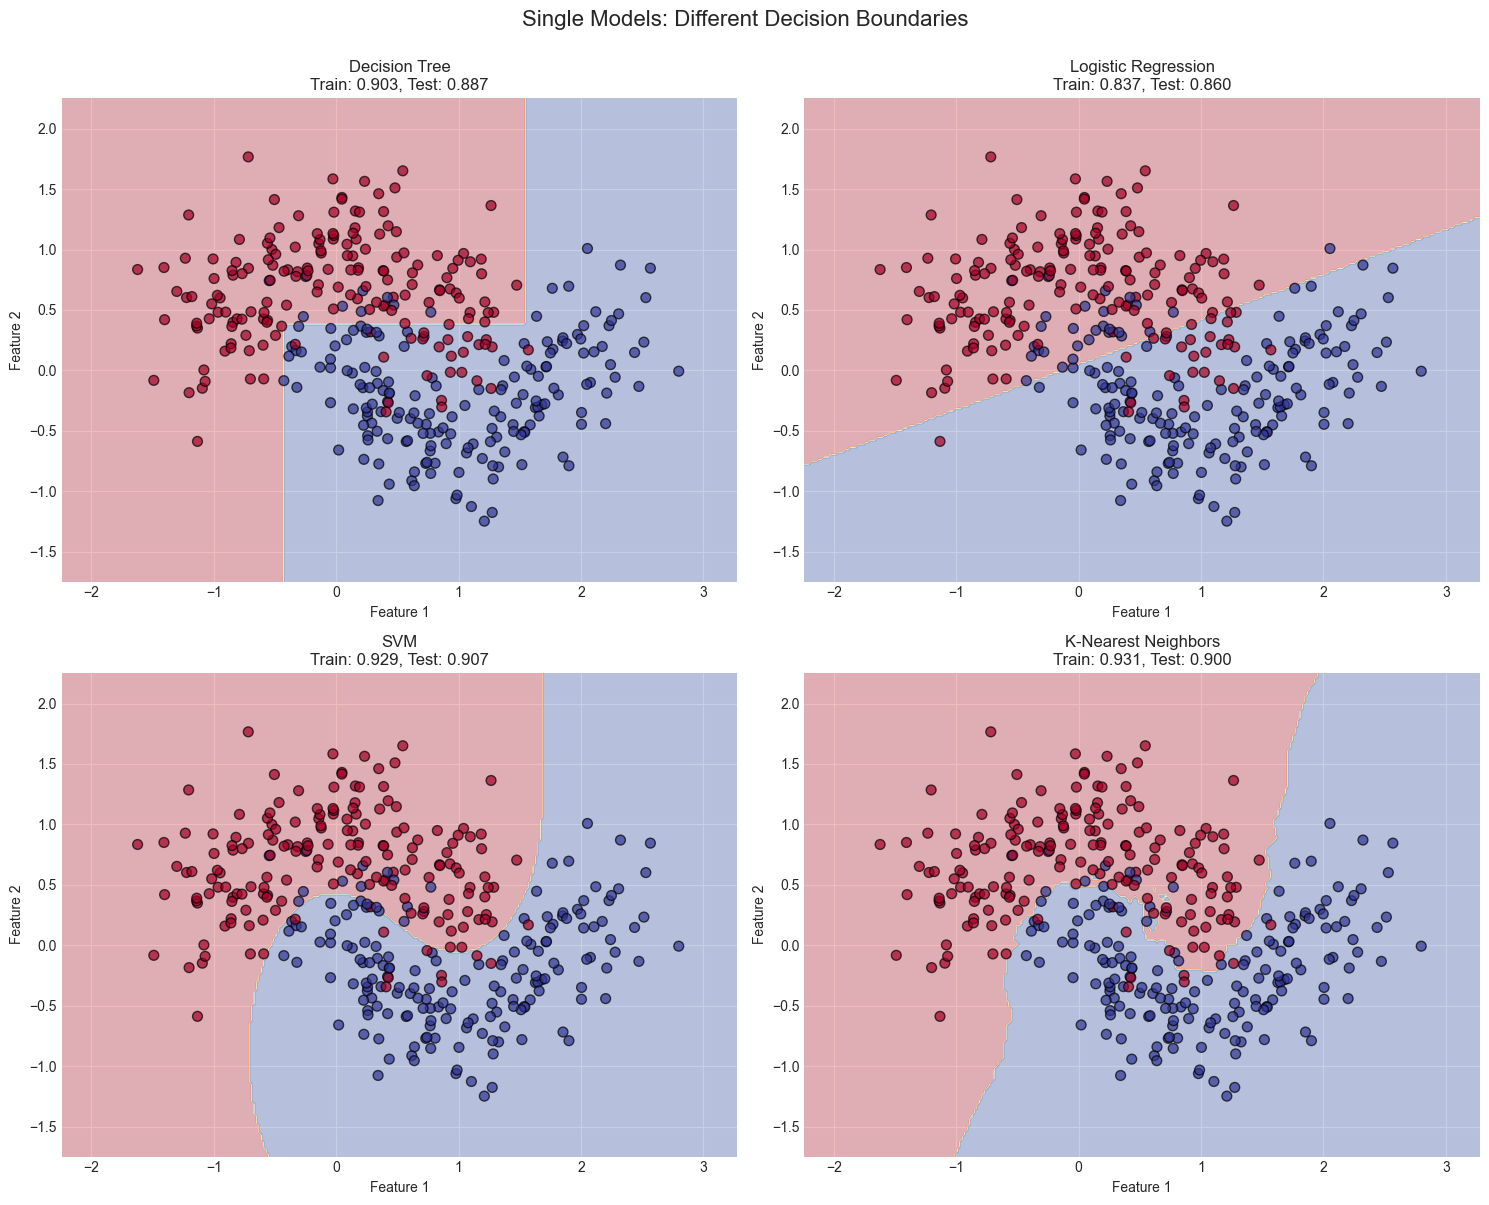

Observation: Each model has strengths and weaknesses.
Ensembling can combine their strengths!


In [2]:
# Generate non-linear dataset
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Try different single models
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Visualize decision boundaries
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Create mesh for decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

for idx, (name, model) in enumerate(models.items()):
    # Train model
    model.fit(X_train, y_train)
    
    # Calculate accuracy
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    # Plot decision boundary
    ax = axes[idx]
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', 
              edgecolors='black', s=50, alpha=0.7)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(f'{name}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Single Models: Different Decision Boundaries', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("Observation: Each model has strengths and weaknesses.")
print("Ensembling can combine their strengths!")

## 2. Bagging (Bootstrap Aggregating)

A single decision tree is a high-variance learner: train it on a slightly different subset of data and you can get a very different tree. That instability is the root of overfitting, the tree latches onto patterns that are accidents of the particular training set.

Bagging exploits this instability rather than fighting it. The idea:

1. Take your training data and draw N random samples *with replacement* (bootstrap samples). Each one is roughly the same size as the original but with some points duplicated and others missing.
2. Train a separate model on each bootstrap sample. Because the samples differ, the models will differ too.
3. At prediction time, let all models vote (classification) or average (regression).

Why does this help? Each individual model still overfits, but they overfit to *different* quirks of their particular sample. When you average many differently-overfit models, the idiosyncratic errors cancel out and what remains is the true signal. It's the statistical equivalent of asking 50 people to estimate the number of jelly beans in a jar. Individual guesses are noisy, but the average is surprisingly accurate.

Bagging is most useful for **unstable** learners (models whose output changes a lot with small changes in training data). Decision trees are the poster child. Bagging a logistic regression, by contrast, barely helps, it's already low-variance.

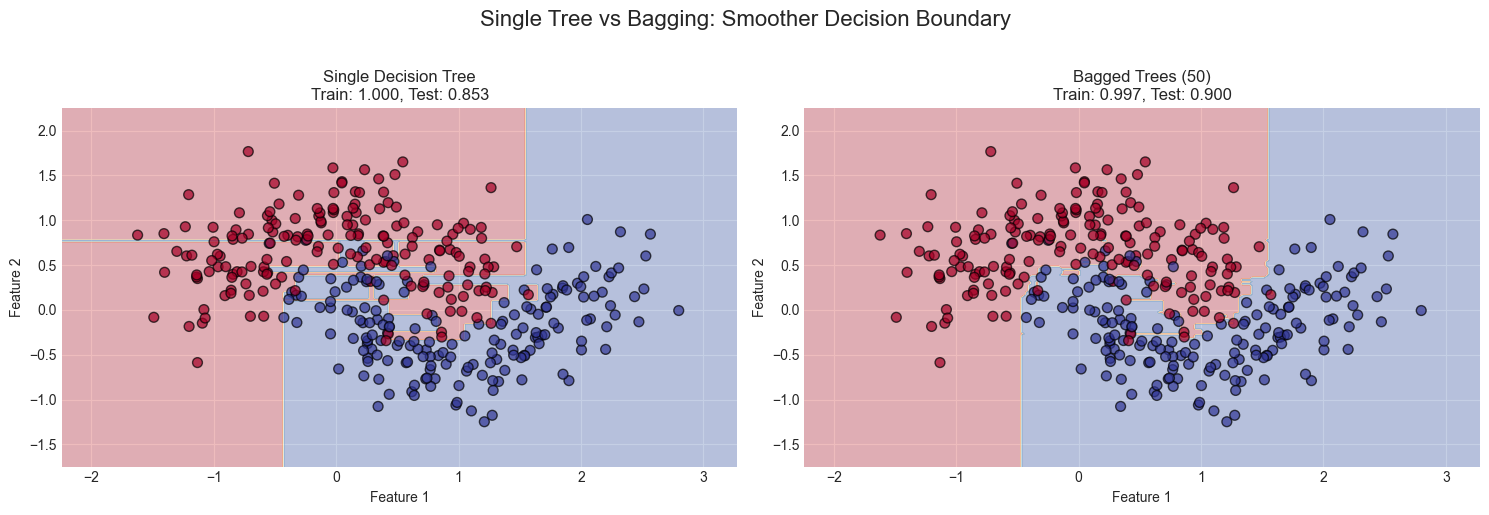


Single Tree Test Accuracy: 0.8533
Bagged Trees Test Accuracy: 0.9000

Improvement: 4.67%


In [3]:
# Compare single tree vs bagged trees
single_tree = DecisionTreeClassifier(random_state=42)
bagged_trees = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

# Train both
single_tree.fit(X_train, y_train)
bagged_trees.fit(X_train, y_train)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (name, model) in enumerate([('Single Decision Tree', single_tree), 
                                      ('Bagged Trees (50)', bagged_trees)]):
    ax = axes[idx]
    
    # Decision boundary
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu',
              edgecolors='black', s=50, alpha=0.7)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    ax.set_title(f'{name}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Single Tree vs Bagging: Smoother Decision Boundary', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSingle Tree Test Accuracy: {single_tree.score(X_test, y_test):.4f}")
print(f"Bagged Trees Test Accuracy: {bagged_trees.score(X_test, y_test):.4f}")
print(f"\nImprovement: {(bagged_trees.score(X_test, y_test) - single_tree.score(X_test, y_test)) * 100:.2f}%")

### Effect of Number of Estimators

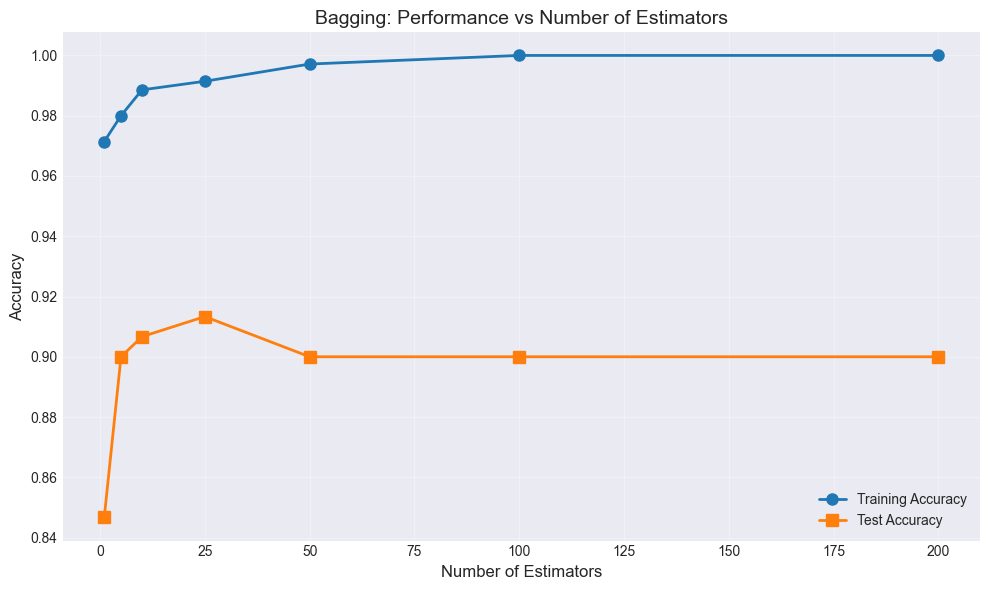

Observation: Performance improves and stabilizes as we add more estimators.


In [4]:
# Test different numbers of estimators
n_estimators_range = [1, 5, 10, 25, 50, 100, 200]
train_scores = []
test_scores = []

for n_estimators in n_estimators_range:
    model = BaggingClassifier(
        DecisionTreeClassifier(random_state=42),
        n_estimators=n_estimators,
        random_state=42
    )
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(n_estimators_range, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Number of Estimators', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Bagging: Performance vs Number of Estimators', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: Performance improves and stabilizes as we add more estimators.")

## 3. Random Forests

Bagging decision trees helps a lot, but there's a subtle problem: if one feature is overwhelmingly strong, every bootstrapped tree will split on it first. The trees end up looking very similar. This because they're *correlated*. Averaging correlated predictions doesn't reduce variance as much as averaging uncorrelated ones.

Random Forests fix this with one extra trick: **at each split, only consider a random subset of features** (typically $\sqrt{p}$ for classification or $p/3$ for regression, where $p$ is the total number of features). This forces each tree to find different paths through the data. Some trees will use features that others ignore entirely. The result is a more diverse forest, and diversity is what makes ensembles work.

Random Forests are probably the single best "grab it off the shelf and go" model in machine learning. They handle non-linear relationships, require very little preprocessing, are robust to outliers, provide feature importance scores, and are hard to catastrophically screw up with bad hyperparameters. When in doubt about what to try first on a new tabular dataset, the answer is usually Random Forest.

Key hyperparameters to be aware of:
- `n_estimators`: more trees = better (with diminishing returns), usually 100-500 is plenty
- `max_features`: controls the diversity/accuracy trade-off per tree
- `max_depth` / `min_samples_split`: control individual tree complexity

In [5]:
# Load a real dataset
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42
)

# Compare Decision Tree vs Random Forest
tree = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Cross-validation scores
tree_cv_scores = cross_val_score(tree, X_bc, y_bc, cv=5)
rf_cv_scores = cross_val_score(rf, X_bc, y_bc, cv=5)

# Train for feature importances
tree.fit(X_train_bc, y_train_bc)
rf.fit(X_train_bc, y_train_bc)

print("Breast Cancer Dataset:")
print("=" * 60)
print(f"{'Model':<25} {'Mean CV Score':>15} {'Std':>10}")
print("=" * 60)
print(f"{'Single Decision Tree':<25} {tree_cv_scores.mean():>15.4f} {tree_cv_scores.std():>10.4f}")
print(f"{'Random Forest (100)':<25} {rf_cv_scores.mean():>15.4f} {rf_cv_scores.std():>10.4f}")
print("\n✅ Random Forest has higher accuracy AND lower variance!")

Breast Cancer Dataset:
Model                       Mean CV Score        Std
Single Decision Tree               0.9173     0.0242
Random Forest (100)                0.9561     0.0228

✅ Random Forest has higher accuracy AND lower variance!


## 4. Boosting

Bagging trains many models independently and averages them. It's a *parallel* strategy that reduces variance. Boosting takes the opposite approach: it trains models **one after another**, and each new model specifically targets the examples that previous models got wrong. It's a *sequential* strategy that reduces bias.

Think of it like a student preparing for an exam. After each practice test, they don't re-study everything equally but instead they focus on the questions they got wrong. Over many rounds, even a mediocre student (a "weak learner") can master the material by relentlessly patching their weaknesses.

## 4.1 AdaBoost (Adaptive Boosting)

AdaBoost is the classic boosting algorithm. Here's how it works in plain terms:

1. Start with a simple model (usually a "stump" a tree with just one split). All training examples have equal weight.
2. After training, look at which examples the model got wrong. **Increase** the weight of the misclassified ones, so the next model is forced to pay more attention to them.
3. Train a new stump on the reweighted data. It will naturally focus on the hard cases.
4. Repeat for N rounds.
5. At prediction time, each stump gets a vote, but not an equal one, **models that made fewer errors get a louder voice, a higher weight**.

The remarkable thing about AdaBoost is that each individual stump is barely better than random, yet combining dozens of them produces a strong classifier. The catch is that the reweighting mechanism makes it sensitive to outliers and noisy labels. If a point is genuinely mislabeled, the algorithm will keep throwing more weight at it, dragging down the whole ensemble.

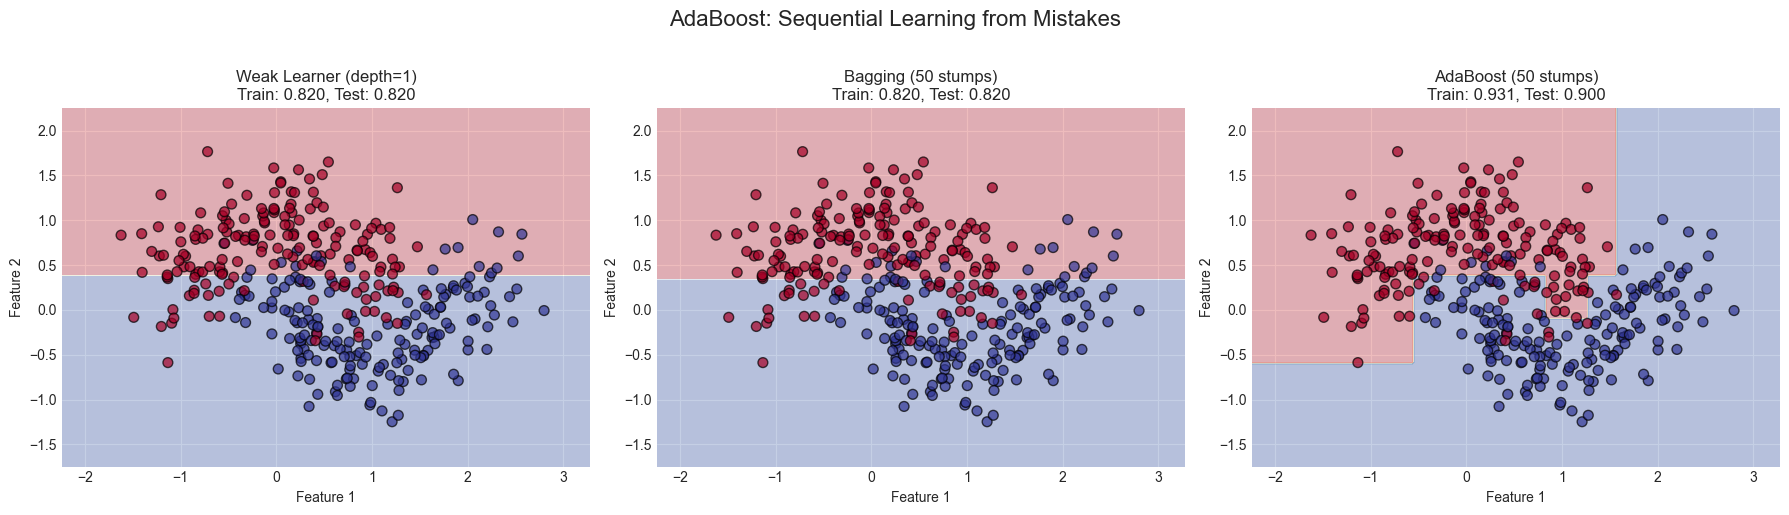


Comparison:
Weak Learner (depth=1)         Test Accuracy: 0.8200
Bagging (50 stumps)            Test Accuracy: 0.8200
AdaBoost (50 stumps)           Test Accuracy: 0.9000


In [6]:
# Compare weak learner, bagging, and AdaBoost
weak_learner = DecisionTreeClassifier(max_depth=1, random_state=42)  # Stump
bagging = BaggingClassifier(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,
    random_state=42
)
adaboost = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,
    random_state=42
)

models_boost = {
    'Weak Learner (depth=1)': weak_learner,
    'Bagging (50 stumps)': bagging,
    'AdaBoost (50 stumps)': adaboost
}

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models_boost.items()):
    model.fit(X_train, y_train)
    
    ax = axes[idx]
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu',
              edgecolors='black', s=50, alpha=0.7)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    ax.set_title(f'{name}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('AdaBoost: Sequential Learning from Mistakes', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\nComparison:")
for name, model in models_boost.items():
    print(f"{name:<30} Test Accuracy: {model.score(X_test, y_test):.4f}")

### AdaBoost: Learning Curve

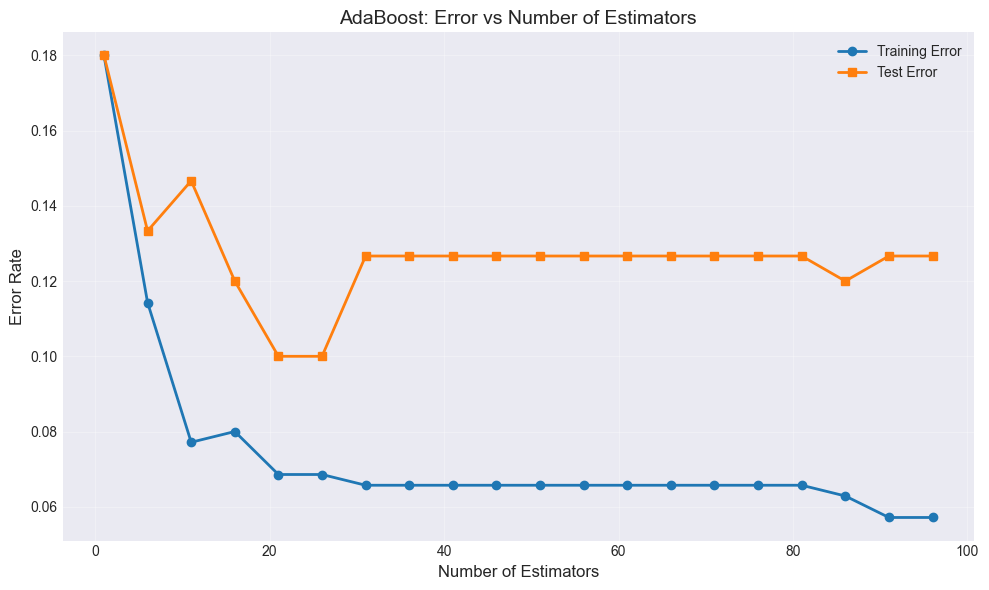

Observation: Error decreases rapidly at first, then plateaus.


In [7]:
# Show how AdaBoost improves with iterations
n_estimators_range = range(1, 101, 5)
train_errors = []
test_errors = []

for n_est in n_estimators_range:
    ada = AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=n_est,
        random_state=42
    )
    ada.fit(X_train, y_train)
    
    train_errors.append(1 - ada.score(X_train, y_train))
    test_errors.append(1 - ada.score(X_test, y_test))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_errors, 'o-', label='Training Error', linewidth=2, markersize=6)
plt.plot(n_estimators_range, test_errors, 's-', label='Test Error', linewidth=2, markersize=6)
plt.xlabel('Number of Estimators', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.title('AdaBoost: Error vs Number of Estimators', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: Error decreases rapidly at first, then plateaus.")

### Gradient Boosting: Learning Rate Effect

## 5. Voting Classifiers

**Voting** combines predictions from multiple different types of models.

### Two Types:

1. **Hard Voting**: Majority vote (most common class)
2. **Soft Voting**: Average predicted probabilities (usually better)

### When to Use:
- When you have diverse models (different algorithms)
- When you want to combine strengths of different approaches
- Simple but effective


Voting Classifier Results:
              Model  Mean CV Score  Std CV Score
      Random Forest       0.956094      0.022839
      Voting (Soft)       0.949061      0.022424
      Voting (Hard)       0.947306      0.022143
        Naive Bayes       0.938519      0.014586
K-Nearest Neighbors       0.927946      0.021763
                SVM       0.912172      0.035444


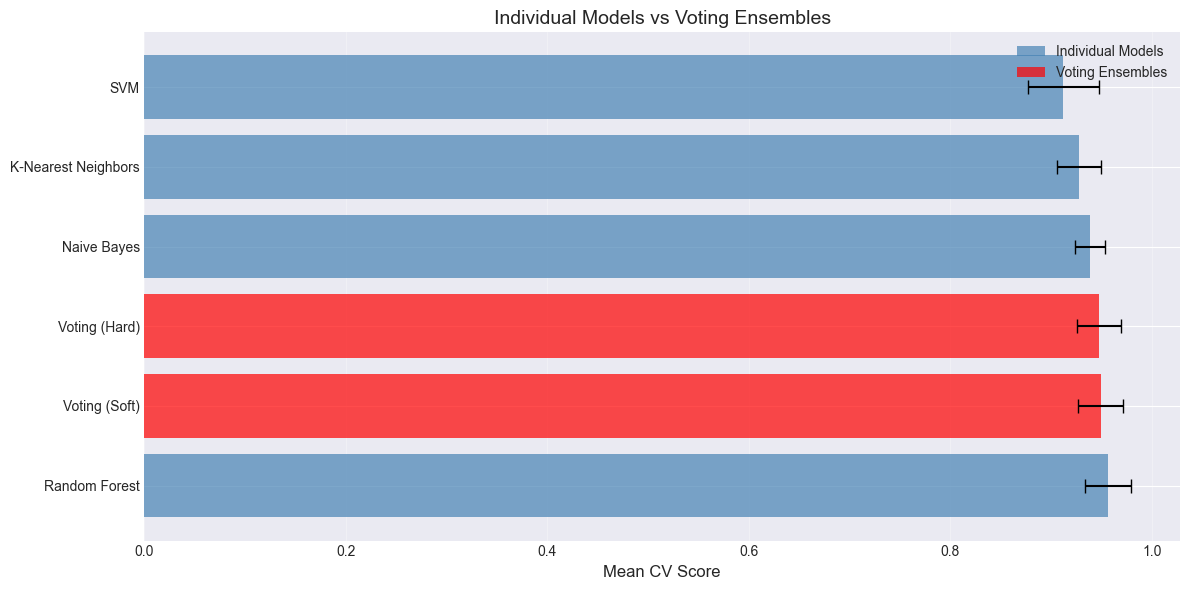


✅ Voting ensembles often outperform individual models!


In [12]:
# Create diverse base models
svm = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()

# Create voting classifiers
voting_hard = VotingClassifier(
    estimators=[('svm', svm), ('rf', rf), ('knn', knn), ('nb', nb)],
    voting='hard'
)

voting_soft = VotingClassifier(
    estimators=[('svm', svm), ('rf', rf), ('knn', knn), ('nb', nb)],
    voting='soft'
)

# Evaluate all models
models_voting = {
    'SVM': svm,
    'Random Forest': rf,
    'K-Nearest Neighbors': knn,
    'Naive Bayes': nb,
    'Voting (Hard)': voting_hard,
    'Voting (Soft)': voting_soft
}

voting_results = []

for name, model in models_voting.items():
    scores = cross_val_score(model, X_bc, y_bc, cv=5)
    voting_results.append({
        'Model': name,
        'Mean CV Score': scores.mean(),
        'Std CV Score': scores.std()
    })

voting_results_df = pd.DataFrame(voting_results).sort_values('Mean CV Score', ascending=False)

print("\nVoting Classifier Results:")
print("=" * 60)
print(voting_results_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if 'Voting' in m else 'steelblue' for m in voting_results_df['Model']]
bars = ax.barh(range(len(voting_results_df)), voting_results_df['Mean CV Score'], 
              color=colors, alpha=0.7)
ax.errorbar(voting_results_df['Mean CV Score'], range(len(voting_results_df)),
           xerr=voting_results_df['Std CV Score'],
           fmt='none', ecolor='black', capsize=5)

ax.set_yticks(range(len(voting_results_df)))
ax.set_yticklabels(voting_results_df['Model'])
ax.set_xlabel('Mean CV Score', fontsize=12)
ax.set_title('Individual Models vs Voting Ensembles', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Individual Models'),
    Patch(facecolor='red', alpha=0.7, label='Voting Ensembles')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print("\n✅ Voting ensembles often outperform individual models!")

## 6. Stacking (Stacked Generalization)

Voting treats all models equally (hard voting) or blends their probabilities with uniform weight (soft voting). But what if one model is great at certain types of examples and terrible at others? Wouldn't it be better to *learn* how to combine them?

That's exactly what **stacking** does. The setup:

1. Train several diverse base models (e.g., Random Forest, SVM, KNN).
2. Collect their predictions on the training set (using cross-validation to avoid leaking).
3. Feed those predictions as *features* into a simple **meta-model** (typically logistic regression or a small linear model).
4. The meta-model learns which base model to trust in which situations.

```
Input → [Random Forest, SVM, KNN] → [0.8, 0.6, 0.9] → Logistic Regression → Final prediction
```

Stacking is the most flexible ensembling approach, but it's also the most prone to overfitting. That's because the meta-model can memorize the training set if you're not careful with the cross-validation. In practice, stacking shines in competitions (where every 0.1% matters) more than in production systems (where simplicity and speed matter more).


Stacking vs Other Methods:
        Model  Mean CV Score  Std CV Score
     Stacking       0.961341      0.021188
Random Forest       0.956094      0.022839
Voting (Soft)       0.952585      0.016209
         K-NN       0.927946      0.021763
          SVM       0.912172      0.035444


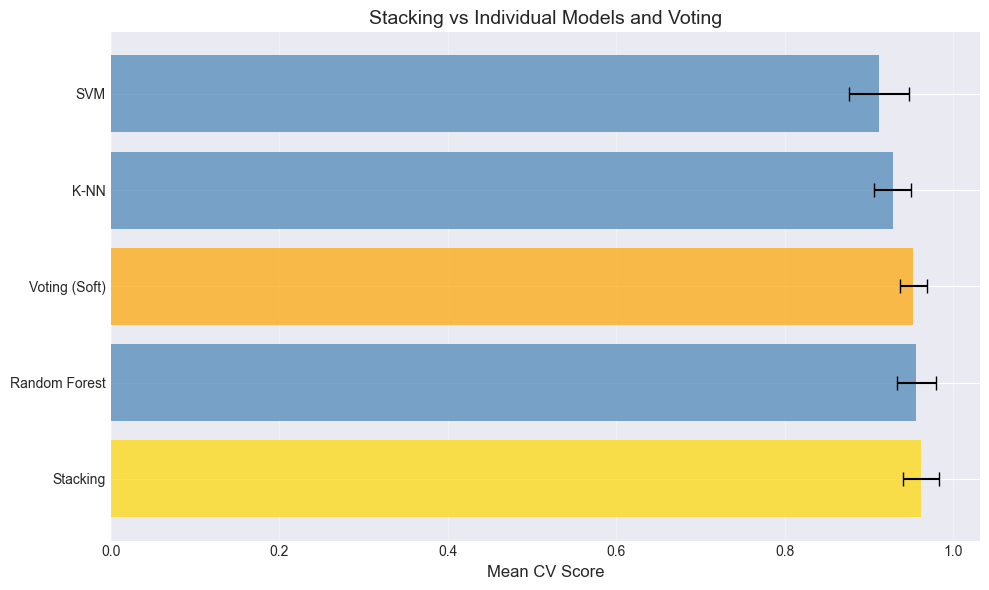

In [23]:
# Create stacking classifier
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

# Meta-model
meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5
)

# Compare with individual models and voting
models_stack = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'K-NN': KNeighborsClassifier(n_neighbors=5),
    'Voting (Soft)': voting_soft,
    'Stacking': stacking
}

stack_results = []

for name, model in models_stack.items():
    scores = cross_val_score(model, X_bc, y_bc, cv=5)
    stack_results.append({
        'Model': name,
        'Mean CV Score': scores.mean(),
        'Std CV Score': scores.std()
    })

stack_results_df = pd.DataFrame(stack_results).sort_values('Mean CV Score', ascending=False)

print("\nStacking vs Other Methods:")
print("=" * 60)
print(stack_results_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
colors = ['gold' if 'Stacking' in m else 'orange' if 'Voting' in m else 'steelblue' 
         for m in stack_results_df['Model']]
bars = plt.barh(range(len(stack_results_df)), stack_results_df['Mean CV Score'], 
               color=colors, alpha=0.7)
plt.errorbar(stack_results_df['Mean CV Score'], range(len(stack_results_df)),
            xerr=stack_results_df['Std CV Score'],
            fmt='none', ecolor='black', capsize=5)

plt.yticks(range(len(stack_results_df)), stack_results_df['Model'])
plt.xlabel('Mean CV Score', fontsize=12)
plt.title('Stacking vs Individual Models and Voting', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 7. Practical Guidelines

### When to Use Each Method:

| Method | Best For | Pros | Cons |
|--------|----------|------|------|
| **Bagging** | Reducing variance of high-variance models | Parallel training, simple | May not improve low-variance models |
| **Random Forest** | General purpose, high performance | Robust, handles non-linearity well | Can overfit on noisy data |
| **AdaBoost** | When you need interpretability | Simple, effective | Sensitive to outliers |
| **Gradient Boosting** | Maximum performance | Often best accuracy | Slower training, easy to overfit |
| **Voting** | Combining diverse models | Simple, often effective | Need diverse base models |
| **Stacking** | Squeezing out last % of performance | Can be very powerful | Complex, risk of overfitting |

### Ensemble Design Principles:

1. **Diversity is key**: Combine models that make different types of errors
2. **Quality matters**: Weak base models → weak ensemble
3. **Balance complexity**: More complex ≠ always better
4. **Use cross-validation**: Prevent overfitting when combining models
5. **Consider computational cost**: Training and prediction time

### Common Mistakes:

- **Using identical models**: No diversity = no benefit
- **Not tuning base models**: Garbage in → garbage out
- **Overfitting on validation**: Too much tuning on same validation set
- **Ignoring inference time**: Some ensembles are slow to predict
- **Combining too many models**: Diminishing returns after a point


## Summary

The core insight behind ensembles is simple: **combining diverse models reduces the impact of any single model's mistakes**. The three strategies we explored: bagging, boosting, and stacking, achieve diversity differently:

**Bagging** (and its supercharged variant, Random Forests) trains the same kind of model on different random slices of the data. The models disagree because they've each seen a slightly different version of the truth. This is a variance-reduction strategy and it is great when your base learner overfits.

**Boosting** (AdaBoost, Gradient Boosting) trains models in sequence, with each one correcting the errors of the previous. This is a bias-reduction strategy. It can turn weak learners into strong ones, but it's greedier and more sensitive to noise.

**Voting and Stacking** combine different *types* of models. Voting is simple and robust. Stacking adds a meta-model that learns the optimal blend, but at the cost of complexity.

A rough performance hierarchy for most tabular problems:

```
Single Decision Tree
    ↓ (Bagging)
Bagged Trees
    ↓ (+ Random Feature Selection)
Random Forest
    ↓ (Sequential Error Correction)
Gradient Boosting / XGBoost
    ↓ (Meta-Learning)
Stacking
```

But remember: more complexity isn't always better. A well-tuned Random Forest will beat a badly-tuned stacking ensemble every time. And 3-5 diverse models often outperform 100 similar ones — **diversity matters more than quantity**.

## Review Questions

1. What is the main principle behind ensemble learning?
2. What's the difference between bagging and boosting?
3. How does Random Forest differ from basic bagging?
4. Why does AdaBoost focus on misclassified examples?
5. What's the difference between hard and soft voting?
6. When would you choose Random Forest over Gradient Boosting?
7. What does the learning rate control in Gradient Boosting?
8. Why is diversity important in ensembles?